In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00


In [ ]:
master_df_final = pd.read_csv('/content/drive/MyDrive/Output (Sentio)/weekly_data_final.csv')

In [ ]:
master_df_final.head()

,Year_Week,Week_Start_Date,Product_ID,Category,Base_Price,Selling_Price,Is_Promo,Qty_Sold,Revenue_Realized,Qty_Sold_Lag1,Qty_Sold_Avg_4W,Sales_Velocity,Views_Last_1W,TryOn_Last_1W,Cart_Adds_Last_1W,Discount_Depth,Price_Change_Rate
0,2022-W04,2022-01-24,4,Feminine,799000,674000.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.156446,0.0
1,2022-W05,2022-01-31,4,Feminine,799000,674000.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.156446,0.0
2,2022-W06,2022-02-07,4,Feminine,799000,674000.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.156446,0.0
3,2022-W07,2022-02-14,4,Feminine,799000,674000.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.156446,0.0
4,2022-W08,2022-02-21,4,Feminine,799000,674000.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.156446,0.0


In [ ]:
master_df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Week          10200 non-null  object 
 1   Week_Start_Date    10200 non-null  object 
 2   Product_ID         10200 non-null  int64  
 3   Category           10200 non-null  object 
 4   Base_Price         10200 non-null  int64  
 5   Selling_Price      10200 non-null  float64
 6   Is_Promo           10200 non-null  int64  
 7   Qty_Sold           10200 non-null  float64
 8   Revenue_Realized   10200 non-null  float64
 9   Qty_Sold_Lag1      10200 non-null  float64
 10  Qty_Sold_Avg_4W    10200 non-null  float64
 11  Sales_Velocity     10200 non-null  float64
 12  Views_Last_1W      10200 non-null  float64
 13  TryOn_Last_1W      10200 non-null  float64
 14  Cart_Adds_Last_1W  10200 non-null  float64
 15  Discount_Depth     10200 non-null  float64
 16  Price_Change_Rate  102

In [ ]:
master_df_final['Price_Ratio'] = master_df_final['Selling_Price'] / master_df_final['Base_Price']

# Khảo sát phân phối dữ liệu

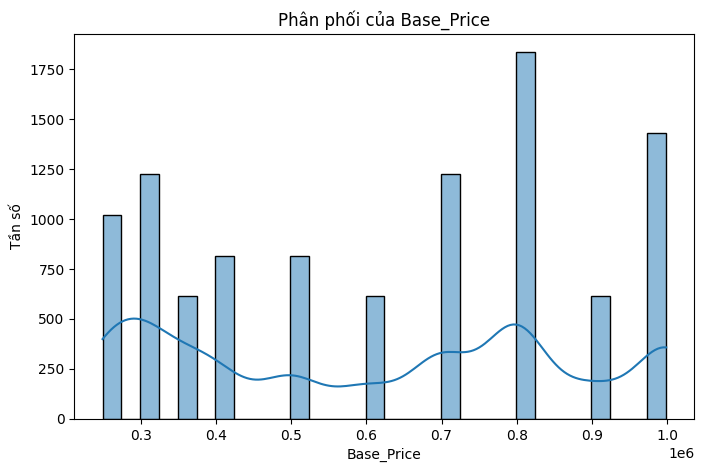

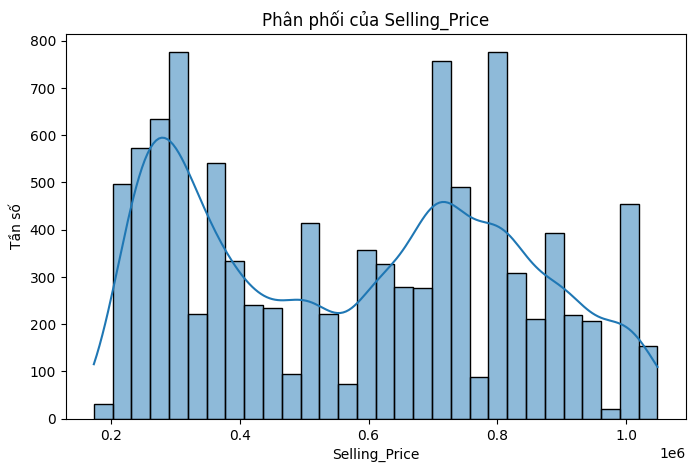

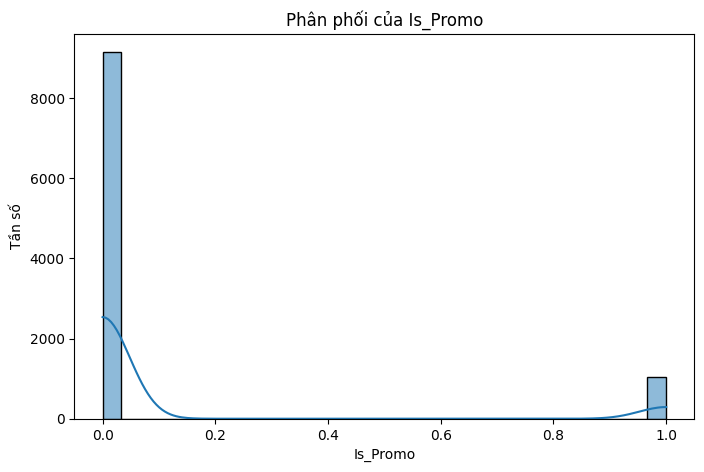

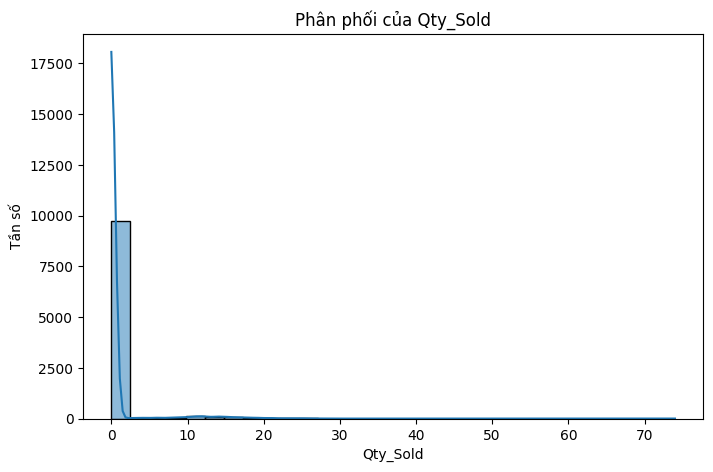

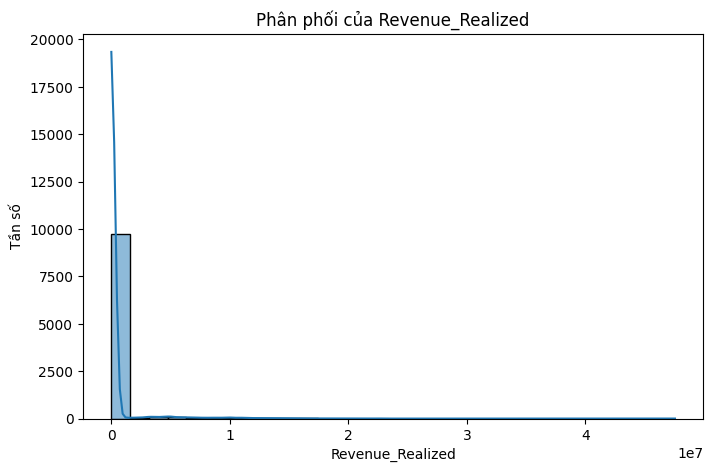

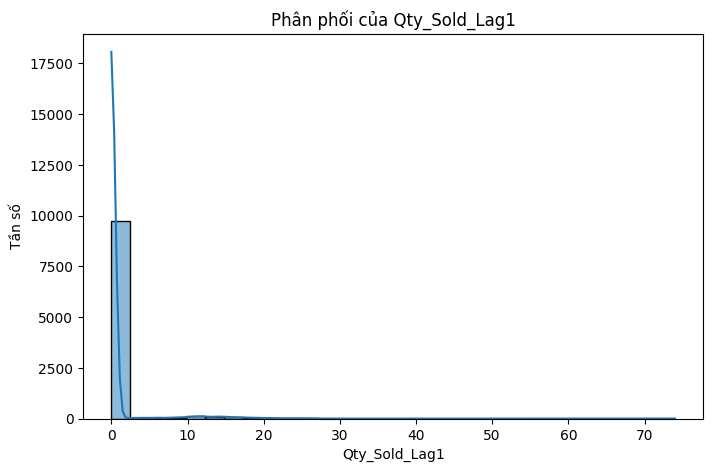

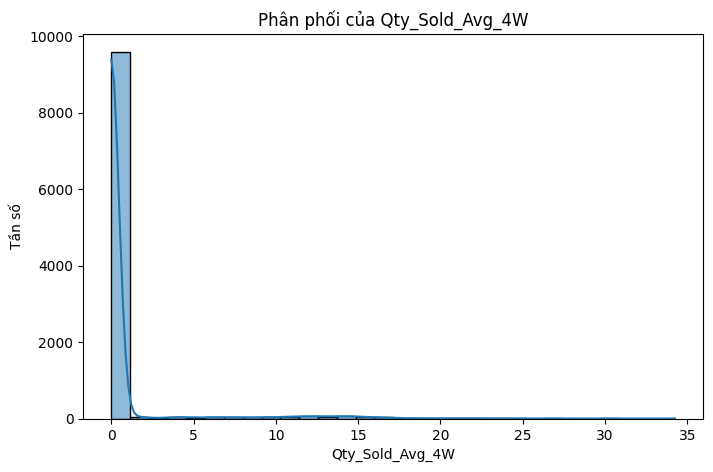

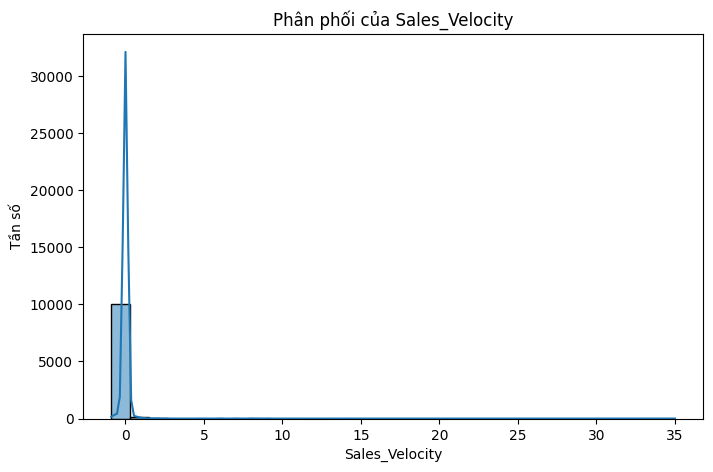

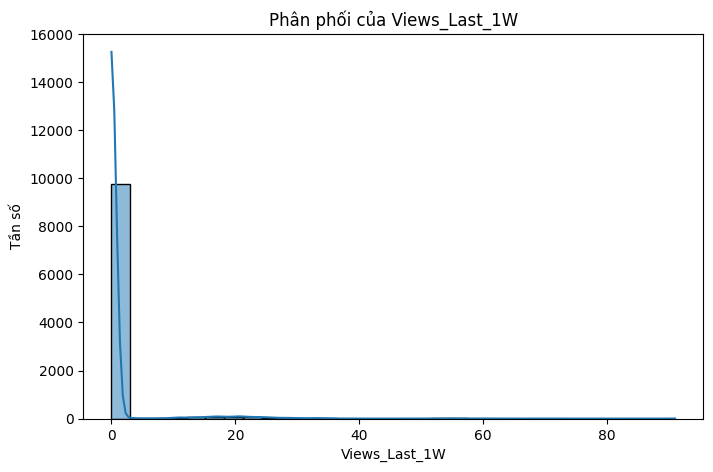

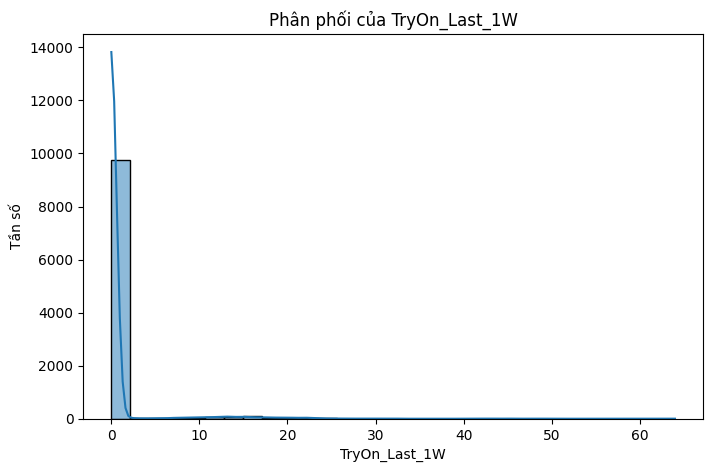

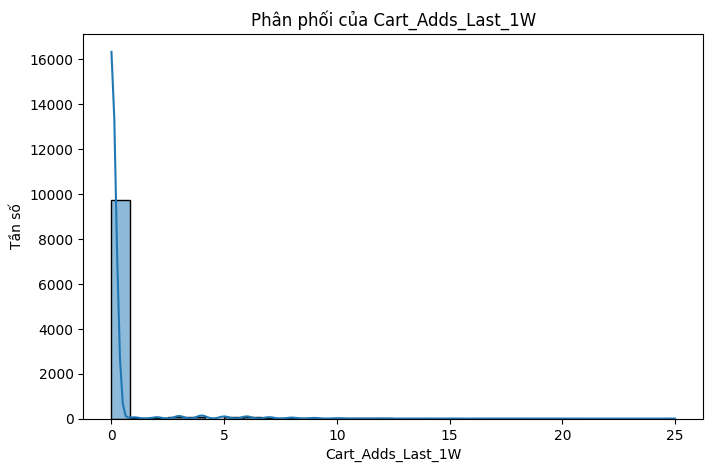

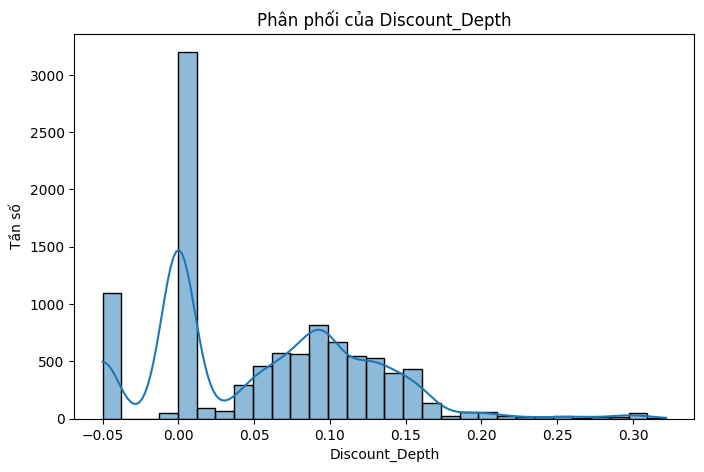

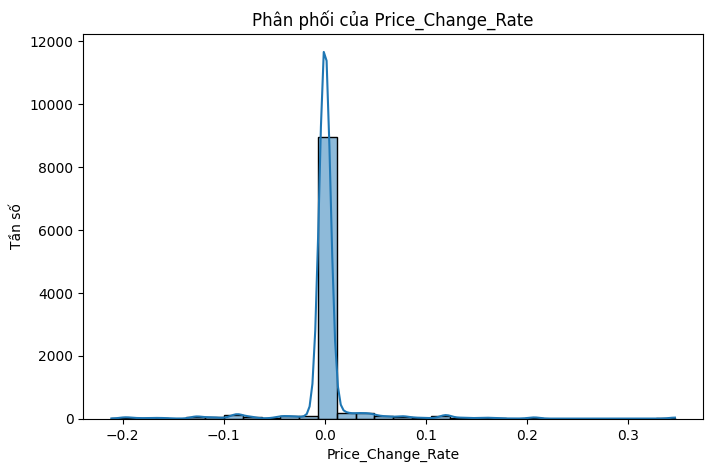

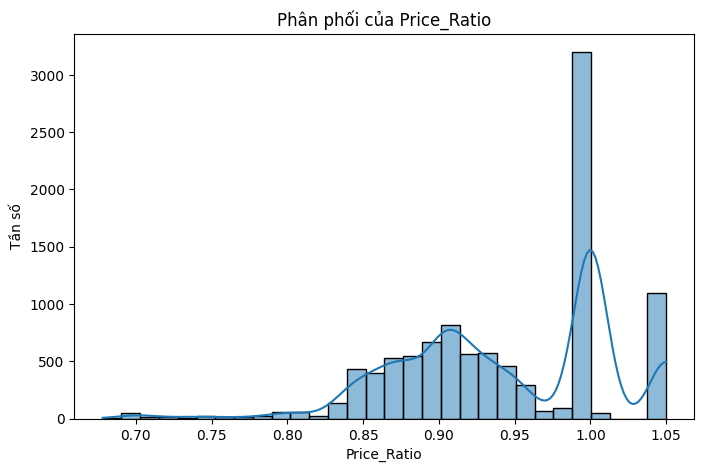

In [ ]:
def plot_numerical_distributions(df, numerical_columns):
    """
    Plots the distribution of numerical columns in a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
        numerical_columns (list): A list of column names to plot.
    """
    for col in numerical_columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Phân phối của {col}')
        plt.xlabel(col)
        plt.ylabel('Tần số')
        plt.show()

# Lấy danh sách các cột số từ master_df_final (loại trừ các cột không cần thiết cho phân phối trực tiếp)
numerical_cols_for_plot = master_df_final.select_dtypes(include=np.number).columns.tolist()
# Loại bỏ các cột ID hoặc những cột đã được xử lý (như Price_Ratio đã tạo)
exclusion_list = ['Product_ID'] # Is_Promo là binary, có thể không cần histplot
numerical_cols_for_plot = [col for col in numerical_cols_for_plot if col not in exclusion_list]

plot_numerical_distributions(master_df_final, numerical_cols_for_plot)


**Nhận xét:**
* Qty_Sold, Revenue_Realized, Qty_Sold_Lag1, Qty_Sold_Avg_4W: Các biểu đồ này đều bị Lệch phải. Đa số các tuần sản phẩm bán chậm (0-5 cái), chỉ có một số ít tuần bán được 50-70 cái.
* Sales_Velocity: Dữ liệu tập trung quanh 0 nhưng có dải giá trị kéo rất xa (lên tới 30-40) --> Nếu dùng cần scale lại
* Các chỉ số về hành vi người dùng khá thưa, thường ở mức 0 lượt.

# Scale dữ liệu và xử lý các trường hợp lệch dữ liệu

In [ ]:
df_processed = master_df_final.copy()

In [ ]:
skewed_features = [
    'Qty_Sold_Lag1', 'Qty_Sold_Avg_4W',
    'Views_Last_1W', 'TryOn_Last_1W', 'Cart_Adds_Last_1W'
]

print("Đang thực hiện Log Transformation cho các cột bị lệch...")
for col in skewed_features:
    # Kiểm tra xem có giá trị âm không (Log không nhận số âm)
    if df_processed[col].min() >= 0:
        # Tạo tên cột mới có hậu tố _Log
        df_processed[f'{col}_Log'] = np.log1p(df_processed[col])
        print(f"-> Đã tạo cột {col}_Log")
    else:
        print(f"-> Bỏ qua {col} vì có giá trị âm.")

# 2. XỬ LÝ OUTLIERS cho Sales_Velocity
# Velocity có thể âm, và Log không xử lý số âm tốt, nên ta dùng Clipping
print("\nĐang xử lý ngoại lai cho Sales_Velocity...")
lower_limit = -1.0 # Giảm tối đa 100% (về 0)
upper_limit = 5.0  # Tăng tối đa 500% (Gấp 5 lần) - Con số này là kinh nghiệm

df_processed['Sales_Velocity_Capped'] = df_processed['Sales_Velocity'].clip(lower=lower_limit, upper=upper_limit)
print(f"-> Đã tạo cột Sales_Velocity_Capped (Range: {lower_limit} to {upper_limit})")

# 3. CẬP NHẬT LẠI DANH SÁCH FEATURES CHO MODEL
# Chúng ta sẽ dùng các cột đã xử lý (_Log, _Capped) thay vì cột gốc
features_new = [
    'Base_Price', 'Category_Encoded', 'Week_of_Year',
    'Is_Promo', 'Price_Change_Rate',

    # Dùng cột đã Log
    'Qty_Sold_Lag1_Log', 'Qty_Sold_Avg_4W_Log',
    'Views_Last_1W_Log', 'TryOn_Last_1W_Log', 'Cart_Adds_Last_1W_Log',

    # Dùng cột đã Cap
    'Sales_Velocity_Capped'
]

print("\nDanh sách Features MỚI sẵn sàng cho Model:", features_new)

Đang thực hiện Log Transformation cho các cột bị lệch...
-> Đã tạo cột Qty_Sold_Lag1_Log
-> Đã tạo cột Qty_Sold_Avg_4W_Log
-> Đã tạo cột Views_Last_1W_Log
-> Đã tạo cột TryOn_Last_1W_Log
-> Đã tạo cột Cart_Adds_Last_1W_Log

Đang xử lý ngoại lai cho Sales_Velocity...
-> Đã tạo cột Sales_Velocity_Capped (Range: -1.0 to 5.0)

Danh sách Features MỚI sẵn sàng cho Model: ['Base_Price', 'Category_Encoded', 'Week_of_Year', 'Is_Promo', 'Price_Change_Rate', 'Qty_Sold_Lag1_Log', 'Qty_Sold_Avg_4W_Log', 'Views_Last_1W_Log', 'TryOn_Last_1W_Log', 'Cart_Adds_Last_1W_Log', 'Sales_Velocity_Capped']


# Feature Selection

Correlation with Selling_Price:
Selling_Price            1.000000
Base_Price               0.982729
Price_Ratio              0.170484
Revenue_Realized         0.061986
Price_Change_Rate        0.033012
Sales_Velocity          -0.002592
Sales_Velocity_Capped   -0.006634
TryOn_Last_1W_Log       -0.009798
Qty_Sold_Lag1_Log       -0.012150
Qty_Sold_Avg_4W_Log     -0.012220
Cart_Adds_Last_1W_Log   -0.012398
Qty_Sold_Lag1           -0.013201
Views_Last_1W_Log       -0.013581
Is_Promo                -0.064744
Discount_Depth          -0.170484
Name: Selling_Price, dtype: float64


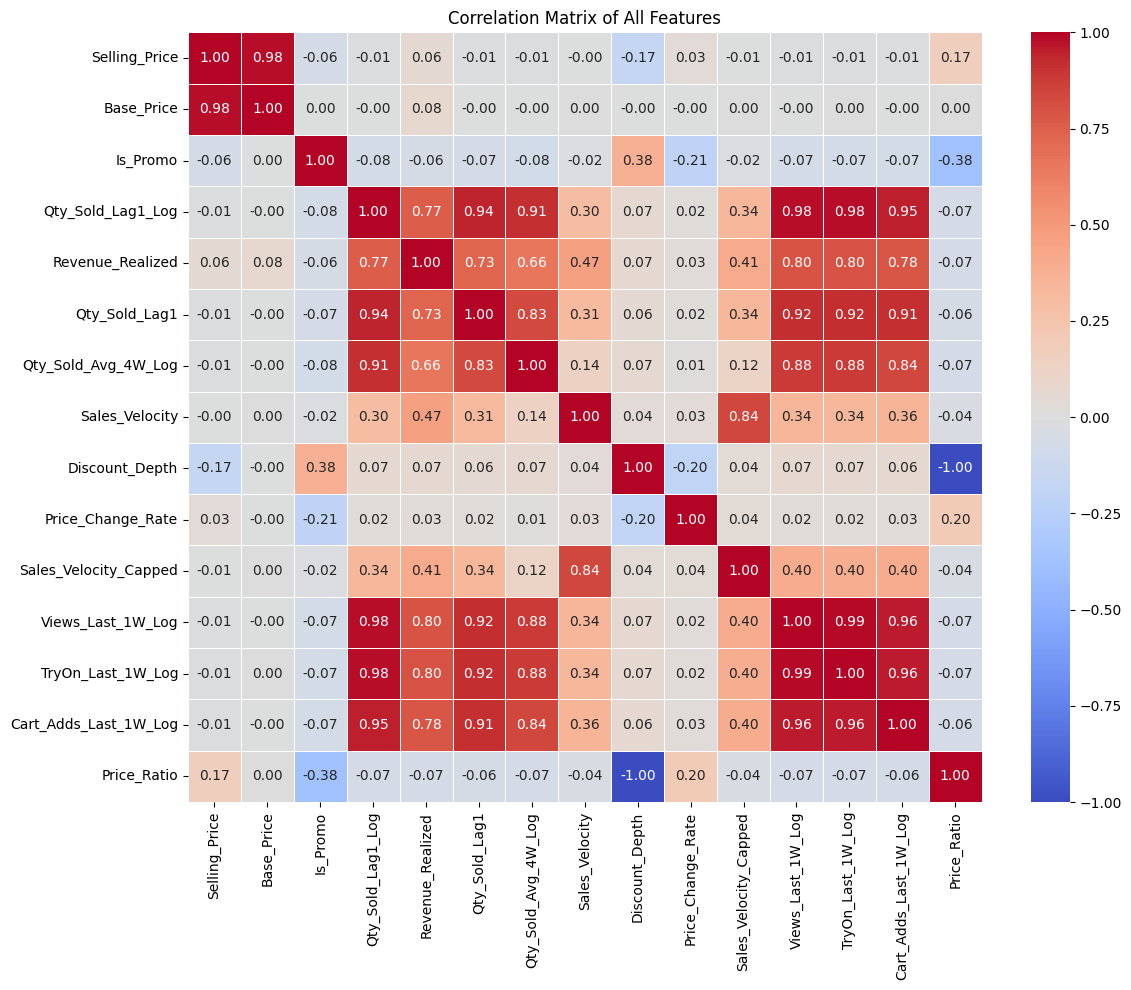

In [ ]:
numerical_cols = [
    'Selling_Price', 'Base_Price', 'Is_Promo',
    'Qty_Sold_Lag1_Log', 'Revenue_Realized',
    'Qty_Sold_Lag1', 'Qty_Sold_Avg_4W_Log', 'Sales_Velocity',
    'Discount_Depth', 'Price_Change_Rate', 'Sales_Velocity_Capped',
    'Views_Last_1W_Log', 'TryOn_Last_1W_Log', 'Cart_Adds_Last_1W_Log', 'Price_Ratio'
]

# Compute correlation
corr_matrix = df_processed[numerical_cols].corr()

# Get correlation with Selling_Price specifically
target_corr = corr_matrix['Selling_Price'].sort_values(ascending=False)

print("Correlation with Selling_Price:")
print(target_corr)

# Save result to CSV for user
target_corr.to_csv('correlation_with_selling_price.csv')

# Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of All Features')
plt.tight_layout()

* **Biến mục tiêu:** Price_Ratio
* **Các biến không được làm input:**
  * Selling_Price: Đây là gốc của biến mục tiêu (Target)
  * Revenue_Realized
  * Discount_Depth
  * Price_Change_Rate
  * Qty_Sold

# Mô hình

## Thiết lập thuộc tính

In [ ]:
df_final = df_processed.copy()

# Xử lý Category: Chuyển từ chữ sang số
le = LabelEncoder()
df_final['Category_Encoded'] = le.fit_transform(df_final['Category'])

# Tạo cột thời gian nếu chưa có
df_final['Week_Start_Date'] = pd.to_datetime(df_final['Week_Start_Date'])
df_final['Month'] = df_final['Week_Start_Date'].dt.month
df_final['Week_of_Year'] = df_final['Week_Start_Date'].dt.isocalendar().week.astype(int)

# 2. XÁC ĐỊNH FEATURES & TARGET
features = [
    # Context
    'Base_Price', 'Category_Encoded', 'Month', 'Week_of_Year', 'Is_Promo',

    # Sales History (Processed)
    'Qty_Sold_Lag1_Log', 'Qty_Sold_Avg_4W_Log', 'Sales_Velocity_Capped',

    # User Behavior (Processed)
    'Views_Last_1W_Log', 'TryOn_Last_1W_Log', 'Cart_Adds_Last_1W_Log'
]

target = 'Price_Ratio'

In [ ]:
print(f"Số lượng features: {len(features)}")
print("Danh sách features:", features)

Số lượng features: 11
Danh sách features: ['Base_Price', 'Category_Encoded', 'Month', 'Week_of_Year', 'Is_Promo', 'Qty_Sold_Lag1_Log', 'Qty_Sold_Avg_4W_Log', 'Sales_Velocity_Capped', 'Views_Last_1W_Log', 'TryOn_Last_1W_Log', 'Cart_Adds_Last_1W_Log']


## Chia train/test (dựa theo time-series)

In [ ]:
df_final = df_final.sort_values(['Week_Start_Date', 'Product_ID'])
weeks = df_final['Week_Start_Date'].unique()

# Lấy 4 tuần cuối làm Test
train_weeks = weeks[:-4]
test_weeks = weeks[-4:]

X_train = df_final[df_final['Week_Start_Date'].isin(train_weeks)][features]
y_train = df_final[df_final['Week_Start_Date'].isin(train_weeks)][target]

X_test = df_final[df_final['Week_Start_Date'].isin(test_weeks)][features]
y_test = df_final[df_final['Week_Start_Date'].isin(test_weeks)][target]

In [ ]:
test_base_prices = df_final[df_final['Week_Start_Date'].isin(test_weeks)]['Base_Price']

print(f"Shape Train: {X_train.shape}")
print(f"Shape Test: {X_test.shape}")

Shape Train: (10000, 11)
Shape Test: (200, 11)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10195
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Base_Price             10000 non-null  int64  
 1   Category_Encoded       10000 non-null  int64  
 2   Month                  10000 non-null  int32  
 3   Week_of_Year           10000 non-null  int64  
 4   Is_Promo               10000 non-null  int64  
 5   Qty_Sold_Lag1_Log      10000 non-null  float64
 6   Qty_Sold_Avg_4W_Log    10000 non-null  float64
 7   Sales_Velocity_Capped  10000 non-null  float64
 8   Views_Last_1W_Log      10000 non-null  float64
 9   TryOn_Last_1W_Log      10000 non-null  float64
 10  Cart_Adds_Last_1W_Log  10000 non-null  float64
dtypes: float64(6), int32(1), int64(4)
memory usage: 898.4 KB


## Thực nghiệm

In [ ]:
def evaluate_model(model, model_name, X_test, y_test, base_prices):
    # Predict
    y_pred_ratio = model.predict(X_test)

    # Convert về giá tiền thật (VND)
    y_true_price = y_test * base_prices
    y_pred_price = y_pred_ratio * base_prices

    # --- CÁC CHỈ SỐ MỚI ---
    # 1. R-squared (R^2)
    r2 = r2_score(y_true_price, y_pred_price)

    # 2. MAPE (Mean Absolute Percentage Error) - Sai số % trung bình
    # Thêm epsilon nhỏ để tránh chia cho 0
    mape = np.mean(np.abs((y_true_price - y_pred_price) / (y_true_price + 1e-10))) * 100


    # Các chỉ số cũ
    mae = mean_absolute_error(y_true_price, y_pred_price)
    rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))

    print(f"--- KẾT QUẢ CHI TIẾT: {model_name} ---")
    print(f"MAE (Sai số tuyệt đối): {mae:,.0f} VND")
    print(f"RMSE (Sai số bình phương): {rmse:,.0f} VND")
    print(f"MAPE (Sai số % trung bình): {mape:.2f}%")
    print(f"R² Score (Độ phù hợp): {r2:.4f} (Max là 1.0)")

    # Plotting
    plt.figure(figsize=(14, 6))
    plt.plot(y_true_price.values[:500], label='Giá Thực Tế (Real)', color='black', alpha=0.6, linewidth=2)
    plt.plot(y_pred_price.values[:500], label=f'Dự Đoán ({model_name})', color='darkorange', linestyle='--', linewidth=2)

    plt.title(f'So sánh Dự đoán vs Thực tế - {model_name} (R2={r2:.2f})')
    plt.ylabel('Giá bán (VND)')
    plt.xlabel('Mẫu kiểm thử (Sample Index)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Trả về dictionary kết quả để so sánh sau này
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

# Dictionary để lưu kết quả
results = {}

Đang training Random Forest...
--- KẾT QUẢ CHI TIẾT: RandomForest ---
MAE (Sai số tuyệt đối): 52,466 VND
RMSE (Sai số bình phương): 65,676 VND
MAPE (Sai số % trung bình): 8.23%
R² Score (Độ phù hợp): 0.9415 (Max là 1.0)


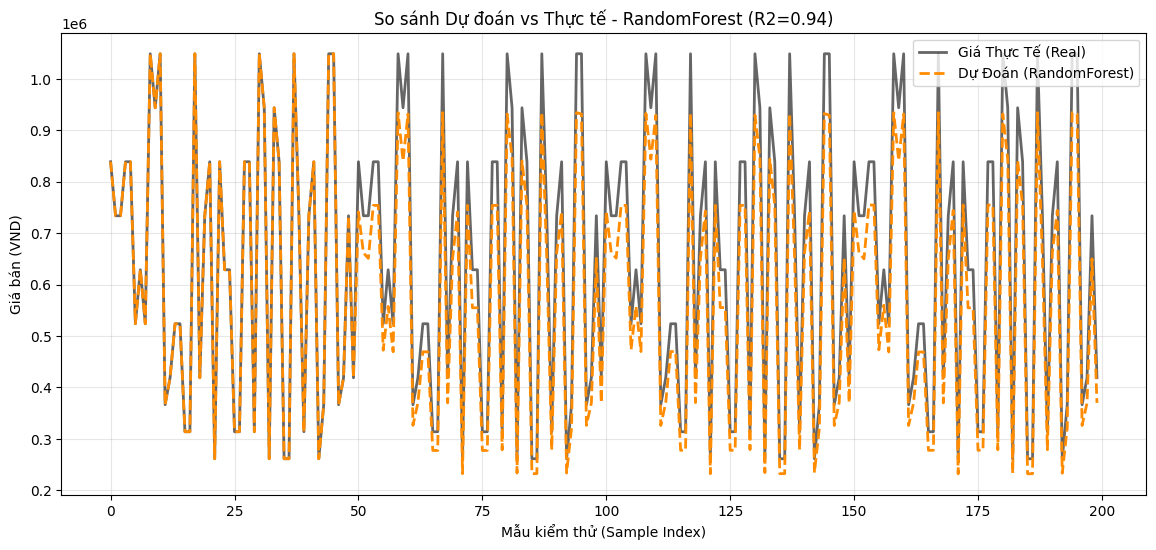

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Khởi tạo & Train
rf_model = RandomForestRegressor(
    n_estimators=200,    # Số lượng cây
    max_depth=10,        # Giới hạn độ sâu để tránh overfitting
    n_jobs=-1,           # Chạy song song full CPU
    random_state=42
)

print("Đang training Random Forest...")
rf_model.fit(X_train, y_train)

# 2. Đánh giá
rf_metrics = evaluate_model(rf_model, "RandomForest", X_test, y_test, test_base_prices)
results['RandomForest'] = rf_metrics

Đang training XGBoost...
--- KẾT QUẢ CHI TIẾT: XGBoost ---
MAE (Sai số tuyệt đối): 57,579 VND
RMSE (Sai số bình phương): 66,506 VND
MAPE (Sai số % trung bình): 9.04%
R² Score (Độ phù hợp): 0.9400 (Max là 1.0)


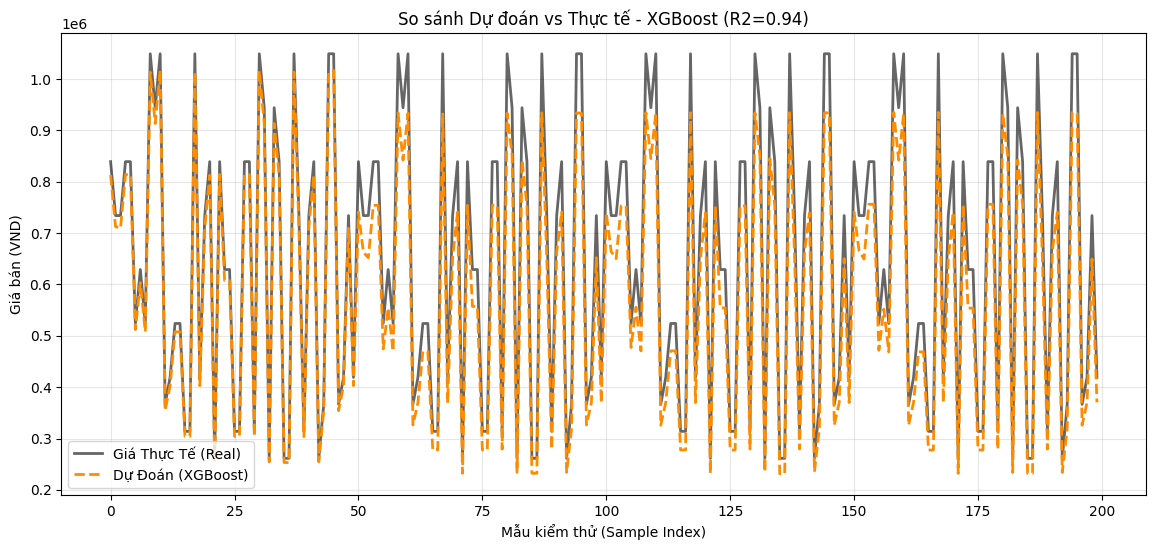

In [ ]:
import xgboost as xgb

# 1. Khởi tạo & Train
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

print("Đang training XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=0 # Tắt in log cho gọn
)

# 2. Đánh giá
xg_metrics = evaluate_model(xgb_model, "XGBoost", X_test, y_test, test_base_prices)
results['XGBoost'] = xg_metrics

Đang training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 392
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 11
[LightGBM] [Info] Start training from score 0.942849
--- KẾT QUẢ CHI TIẾT: LightGBM ---
MAE (Sai số tuyệt đối): 55,445 VND
RMSE (Sai số bình phương): 65,360 VND
MAPE (Sai số % trung bình): 8.65%
R² Score (Độ phù hợp): 0.9420 (Max là 1.0)


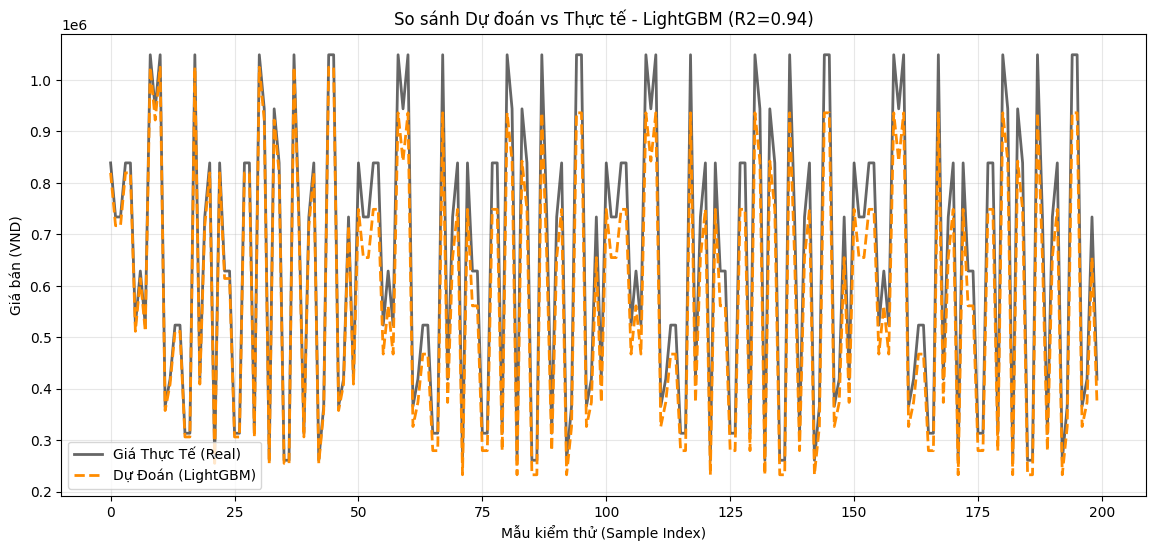

In [ ]:
import lightgbm as lgb

# 1. Khởi tạo & Train
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,       # Tham số quan trọng của LightGBM
    max_depth=-1,
    n_jobs=-1,
    random_state=42
)

print("Đang training LightGBM...")
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)] # Sửa lỗi cú pháp bản mới
)

# 2. Đánh giá
light_metrics = evaluate_model(lgb_model, "LightGBM", X_test, y_test, test_base_prices)
results['LightGBM'] = light_metrics

Đang training CatBoost...
--- KẾT QUẢ CHI TIẾT: CatBoost ---
MAE (Sai số tuyệt đối): 61,706 VND
RMSE (Sai số bình phương): 67,849 VND
MAPE (Sai số % trung bình): 9.64%
R² Score (Độ phù hợp): 0.9375 (Max là 1.0)


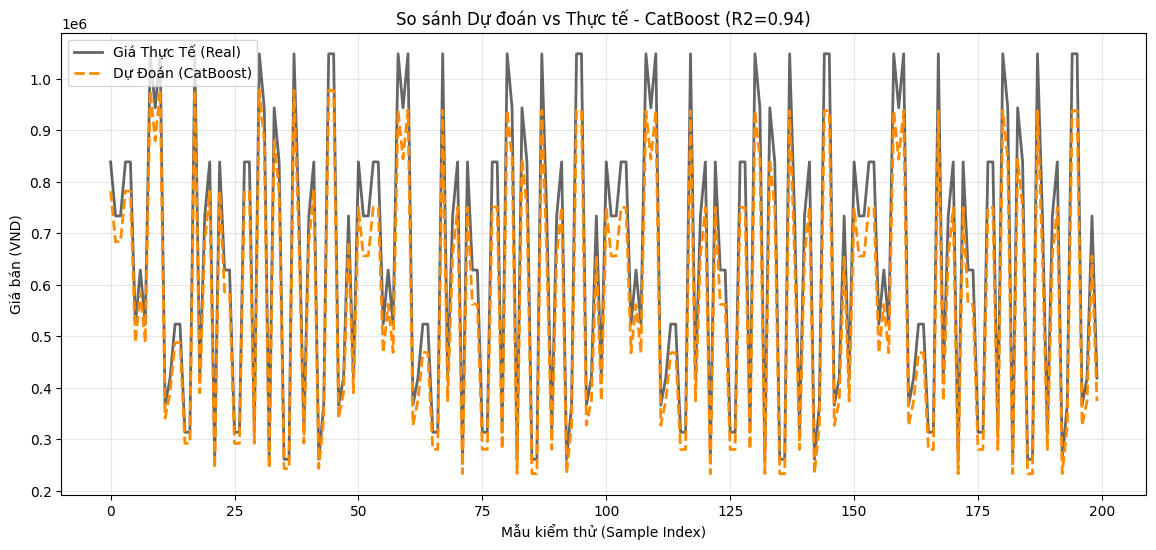

In [ ]:
from catboost import CatBoostRegressor

# 1. Khởi tạo & Train
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=0, # Tắt log in ra màn hình
    random_seed=42
)

print("Đang training CatBoost...")
cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

# 2. Đánh giá
cat_metrics = evaluate_model(cat_model, "CatBoost", X_test, y_test, test_base_prices)
results['CatBoost'] = cat_metrics

# Lưu trữ

In [ ]:
import joblib
import os

save_path = '/content/drive/MyDrive/Model'

# Tạo thư mục trên Drive nếu chưa có
os.makedirs(save_path, exist_ok=True)

# 3. Lưu Model Random Forest
joblib.dump(lgb_model, os.path.join(save_path, 'lgb_price_forecast_v1.pkl'))

# 4. Lưu Label Encoder
joblib.dump(le, os.path.join(save_path, 'category_encoder_v1.pkl'))

print(f"✅ Đã lưu thành công vào: {save_path}")

✅ Đã lưu thành công vào: /content/drive/MyDrive/Model
